This notebook recreates the ABC inference procedure from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import data_preprocessing.ABC_priors_and_functions as ABC
import data_preprocessing.plotting_functions as ABC_plot

SMALL_SIZE = 15
MEDIUM_SIZE = 15
BIGGER_SIZE = 21

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In the next code block, uncomment whichever inference portion you wish to run.

In [8]:
inference_portion = "pulse"
#inference_portion = "chase"

The following code block will run number_sims number of simulations, and is the ABC time bottleneck. 

On a 4 core laptop (8.00GB of RAM, 1.70GHz CPU):

- Setting number_sims = 100 takes ~10 minutes to run
- Setting number_sims = 500 takes ~40 minutes to run

Set this parameter according to your own time constraints, but the larger it is the better the ABC will perform.

Stochastic three population model will take longer to run as it is running an inhomogeneous Gillespie rather than a standard Gillespie.

If you wish to set number_sims to be large (eg num_sims> 5000), we recommend running in batches and saving intermediary products to avoid memory issues. In our paper, we set number_sims=500000 split into 100 batches, which can take up to 2 hours to run with 128 cores. 

In [13]:
number_sims = 100
simulated_summaries, simulated_pulse_params, simulated_chase_params = ABC.run(number_sims = number_sims, inference_portion = inference_portion)

pulse
Simulation 76 Finished
Simulation 13 Finished
Simulation 52 Finished
Simulation 14 Finished
Simulation 53 Finished
Simulation 15 Finished
Simulation 16 Finished
Simulation 64 Finished
Simulation 0 Finished
Simulation 39 Finished
Simulation 88 Finished
Simulation 77 Finished
Simulation 40 Finished
Simulation 41 Finished
Simulation 26 Finished
Simulation 78 Finished
Simulation 54 Finished
Simulation 55 Finished
Simulation 27 Finished
Simulation 28 Finished
Simulation 17 Finished
Simulation 18 Finished
Simulation 56 Finished
Simulation 65 Finished
Simulation 19 Finished
Simulation 57 Finished
Simulation 79 Finished
Simulation 80 Finished
Simulation 89 Finished
Simulation 90 Finished
Simulation 81 Finished
Simulation 82 Finished
Simulation 1 Finished
Simulation 2 Finished
Simulation 58 Finished
Simulation 59 Finished
Simulation 60 Finished
Simulation 66 Finished
Simulation 67 Finished
Simulation 68 Finished
Simulation 69 Finished
Simulation 61 Finished
Simulation 3 Finished
Simulatio

The following code block will accept 'proportion_accepted' number of simulations out of the 'number_sims' simulations you ran in the above code block.

The smaller this parameter is, the better the accepted parameters will be, but the less accepted parameters you will have.

Adjust this parameter as you see fit.

In our paper, proportion_accepted = 0.001

In [17]:
proportion_accepted=0.1

accepted_pulse_params, accepted_chase_params, bandwidth = ABC.ABC_reject(simulated_summaries, simulated_pulse_params, simulated_chase_params, proportion_accepted, inference_portion = inference_portion)

The next code block plots prior and posterior distributions based on the previous simulations

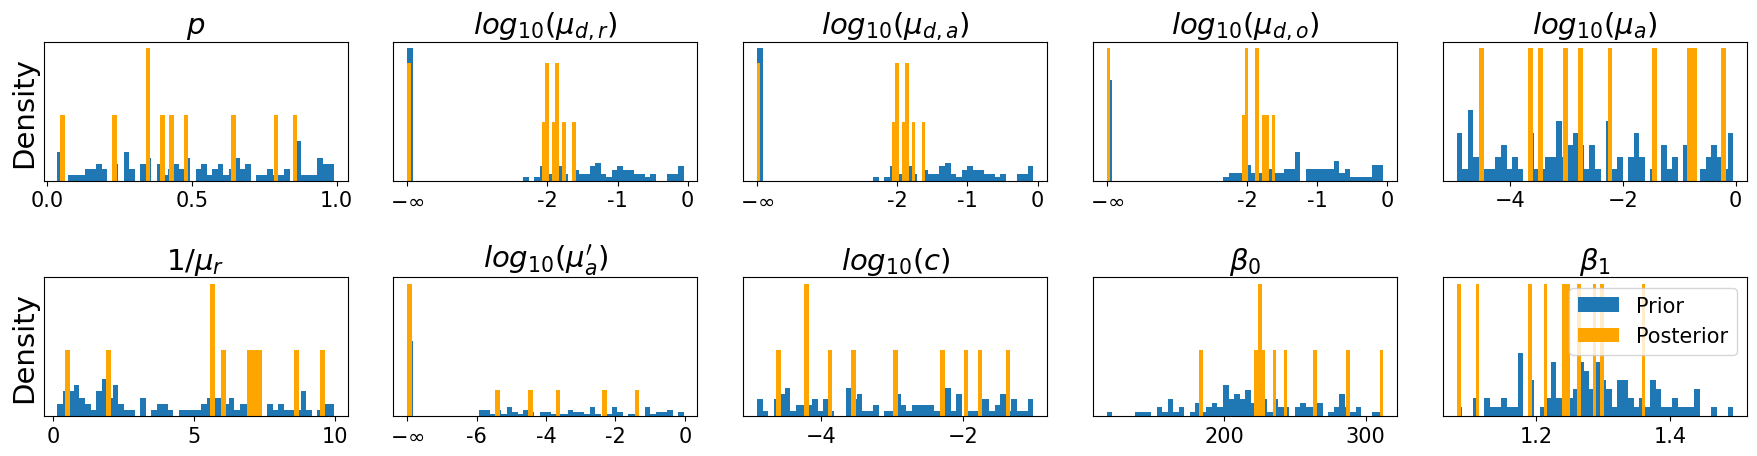

In [18]:
ABC_plot.extended_three_population_posteriors(simulated_pulse_params, accepted_pulse_params, simulated_pulse_params, accepted_pulse_params, simulated_chase_params, accepted_chase_params, mode = inference_portion, dimensions = 1, MAP = False, death_mode = 0)

pulse plot


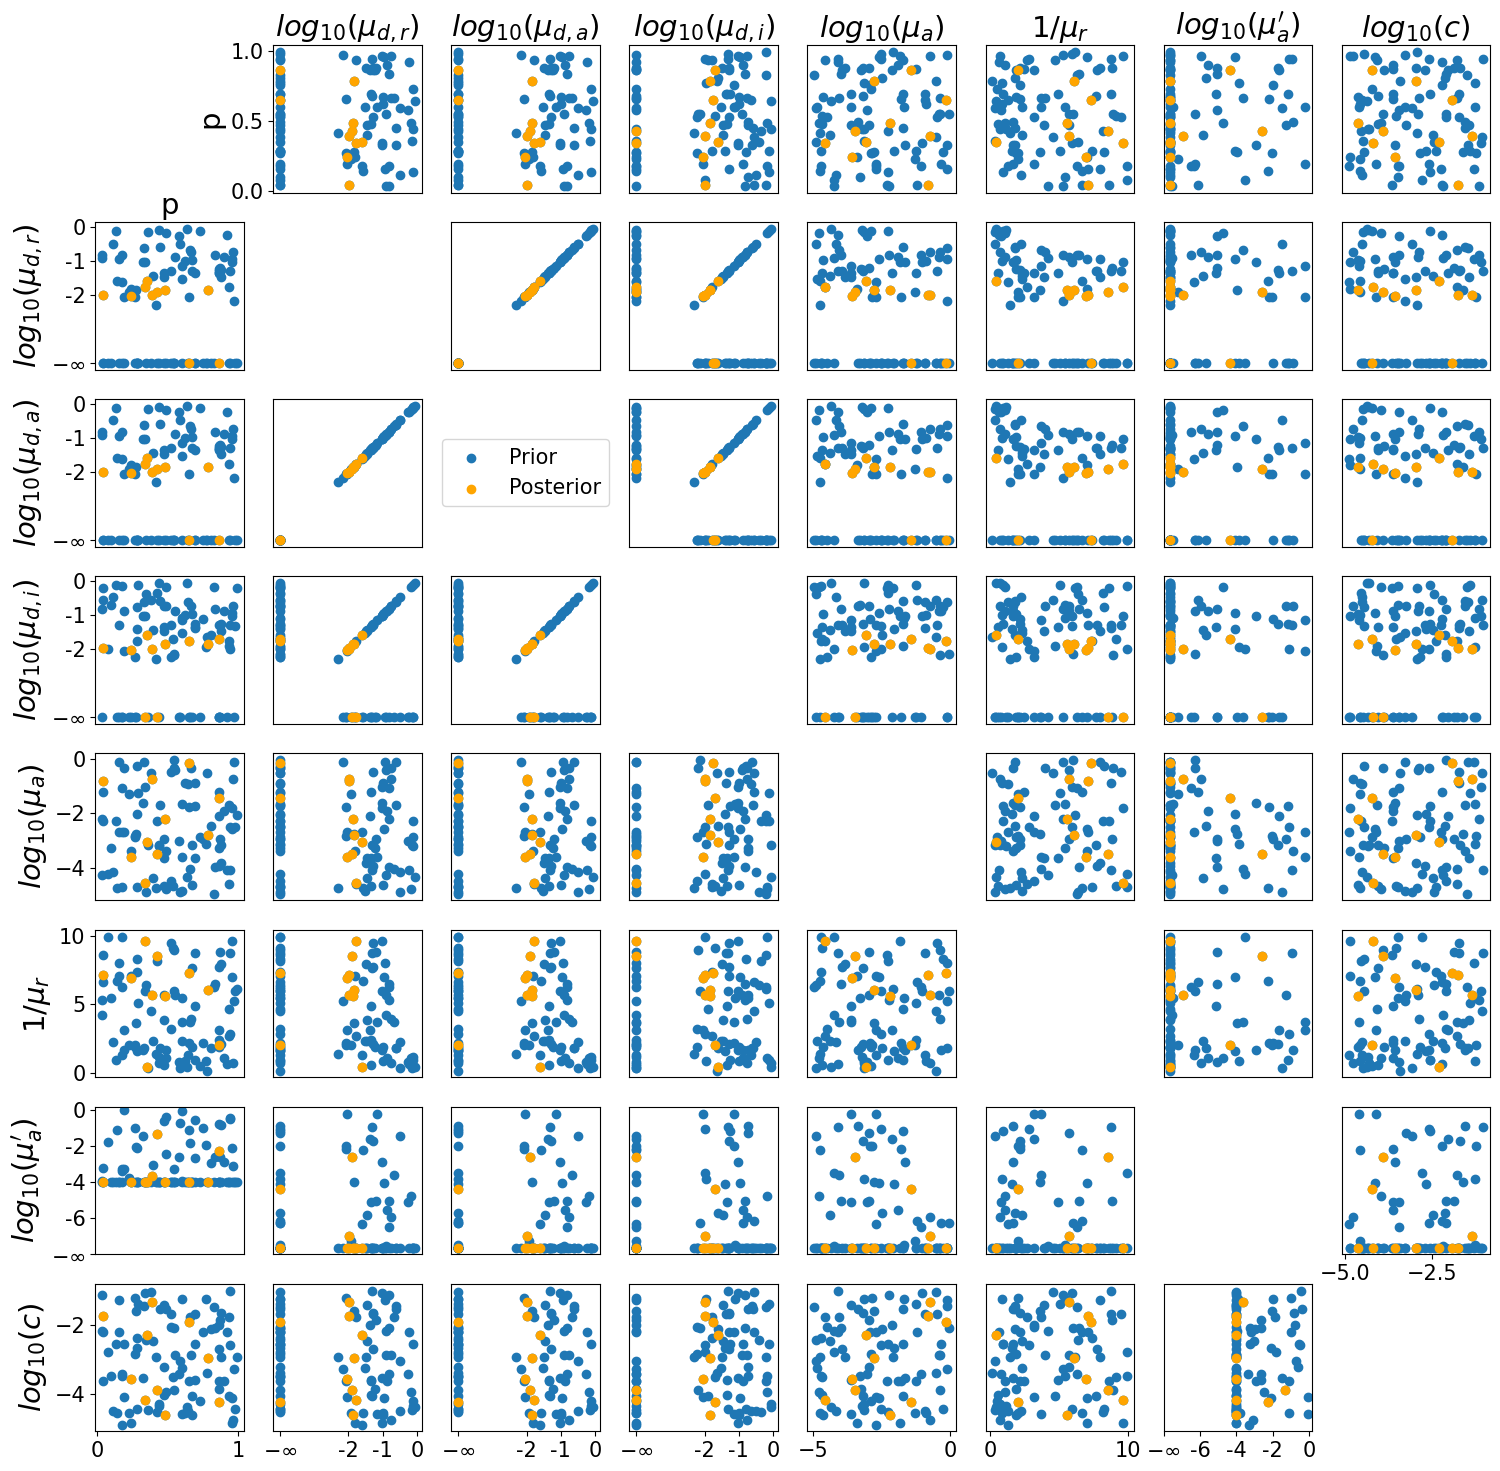

In [19]:
ABC_plot.extended_three_population_posteriors(simulated_pulse_params, accepted_pulse_params, simulated_pulse_params, accepted_pulse_params, simulated_chase_params, accepted_chase_params, mode = inference_portion, dimensions = 2, MAP = False, death_mode = 0)

In [2]:

nucleoid_trajectories, edu_trajectories, peak1, variance_statistics = ABC.posterior_predictive(num_samples = 10, inference_portion = "pulse", mode = "full")

7/10
8/10
1/10
6/10
3/10
5/10
10/10
2/10
4/10
9/10


In [ ]:
nucleoid_trajectories, edu_trajectories, edu_proportions, peak1_0day, peak1_4day, variance_statistics = ABC.posterior_predictive(num_samples = 500, inference_portion = "chase", mode = "full")